# DATA ANALYSIS

## Exploration and preprocessing of the dataset

In [19]:
import os
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    GITHUB_USER = "SinghSahiljit44"  # Es. sahiljit
    REPO_NAME = "Weather_forecasting"
    REPO_URL = f"https://github.com/{GITHUB_USER}/{REPO_NAME}.git"

    # Clona la repository se non è già stata clonata nella sessione
    if not os.path.exists(REPO_NAME):
        !git clone {REPO_URL}

    # Cambia la directory di lavoro nella root del progetto
    os.chdir(REPO_NAME)
    
    # Installa le dipendenze necessarie nell'ambiente di Colab
    !pip install -q -r requirements.txt
    
    PROJECT_ROOT = Path.cwd()
else:
    # --- CONFIGURAZIONE LOCALE  ---
    PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
    os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(f" [OK] Ambiente rilevato: {'Google Colab' if IN_COLAB else 'Locale'}")
print(f" [OK] Directory di lavoro impostata a: {Path.cwd()}")

 [OK] Ambiente rilevato: Locale
 [OK] Directory di lavoro impostata a: c:\Users\sahil\GitHub\Weather_forecasting


In [20]:
#Doesn't work on colab this cell
from src.data.dataset import load_hourly

# Carica il dataframe con i dati orari
df_hourly = load_hourly()

# Mostra le prime 48 ore (i primi due giorni completi)
df_hourly.head(48)

,t2m,skt,stl1,stl2,stl3,stl4,swvl1,swvl2,swvl3,swvl4,pev,e,tp
time,,,,,,,,,,,,,
1990-01-01 00:00:00,3.691919,2.302026,4.594263,6.877100,10.465723,16.038232,0.435532,0.417847,0.331802,0.314011,-0.877649,-0.366595,0.556895
1990-01-01 01:00:00,3.363550,1.943262,4.407495,6.798730,10.456079,16.034937,0.435349,0.417847,0.331833,0.314011,0.002131,0.002133,0.005156
1990-01-01 02:00:00,2.892114,1.389429,4.137476,6.712305,10.446436,16.031641,0.435135,0.417862,0.331848,0.314011,0.004981,0.004981,0.005418
1990-01-01 03:00:00,3.162744,1.776025,4.190332,6.631738,10.436792,16.028345,0.434967,0.417862,0.331863,0.314011,0.007249,0.007248,0.007827
1990-01-01 04:00:00,3.888330,2.631738,4.450952,6.572656,10.428979,16.025049,0.435364,0.417877,0.331879,0.314011,0.008661,0.008662,0.062440
1990-01-01 05:00:00,4.498682,3.321436,4.708276,6.531396,10.419092,16.021753,0.437424,0.417892,0.331894,0.314011,0.009891,0.009893,0.238009
1990-01-01 06:00:00,5.317163,4.297266,5.101099,6.513818,10.409204,16.016626,0.440689,0.417938,0.331909,0.314011,0.008993,0.008994,0.492454
1990-01-01 07:00:00,5.892480,4.971582,5.426172,6.513818,10.399194,16.013330,0.442307,0.417984,0.331940,0.314011,0.007238,0.007237,0.633188
1990-01-01 08:00:00,6.500513,5.696436,5.792871,6.535913,10.389185,16.010034,0.443939,0.418060,0.331955,0.314011,0.003539,0.003539,0.779666


In [21]:
# No missing values 
#Doesn't work on colab this cell 
df_hourly.isnull().sum()

t2m      0
skt      0
stl1     0
stl2     0
stl3     0
stl4     0
swvl1    0
swvl2    0
swvl3    0
swvl4    0
pev      0
e        0
tp       0
dtype: int64

In [22]:
from src.data.preprocessing import load_daily

# Carica il dataframe con i dati giornalieri
df_daily = load_daily()

# Mostra ultimi 2 giorni
df_daily.tail(2)

,t2m_mean,t2m_min,t2m_max,tp_mm,e_mm,pev_mm,skt_mean,stl1_mean,stl2_mean,stl3_mean,stl4_mean,swvl1_mean,swvl2_mean,swvl3_mean,swvl4_mean
date,,,,,,,,,,,,,,,
2025-12-29,7.517165,2.175928,13.133081,0.000852,-0.609646,-1.373537,5.763895,7.700311,9.291325,12.367039,18.182240,0.423934,0.419802,0.381882,0.304296
2025-12-30,6.777755,1.362451,12.849390,0.776327,-0.636903,-1.522161,5.722381,6.934641,8.187143,12.166803,18.094665,0.421186,0.418313,0.381873,0.304318


### ERA5-Land Dataset Variables Summary

| Variable Code | Long Name | Unit (in dataset) | Processing Type | Description |
|---|---|---|---|---|
| **t2m** | 2 metre temperature | °C | Instantaneous | Temperature of air at 2 m above the surface. |
| **skt** | Skin temperature | °C | Instantaneous | Temperature of the surface of the Earth. |
| **stl1** | Soil temperature level 1 | °C | Instantaneous | Temperature of soil in layer 1 (0 – 7 cm). |
| **stl2** | Soil temperature level 2 | °C | Instantaneous | Temperature of soil in layer 2 (7 – 28 cm). |
| **stl3** | Soil temperature level 3 | °C | Instantaneous | Temperature of soil in layer 3 (28 – 100 cm). |
| **stl4** | Soil temperature level 4 | °C | Instantaneous | Temperature of soil in layer 4 (100 – 289 cm). |
| **swvl1** | Volumetric soil water layer 1 | m³/m³ | Instantaneous | Volume fraction of water in soil layer 1 (0 – 7 cm). |
| **swvl2** | Volumetric soil water layer 2 | m³/m³ | Instantaneous | Volume fraction of water in soil layer 2 (7 – 28 cm). |
| **swvl3** | Volumetric soil water layer 3 | m³/m³ | Instantaneous | Volume fraction of water in soil layer 3 (28 – 100 cm). |
| **swvl4** | Volumetric soil water layer 4 | m³/m³ | Instantaneous | Volume fraction of water in soil layer 4 (100 – 289 cm). |
| **pev** | Potential evaporation | mm | Accumulated | Evaporation if water supply were unlimited. |
| **e** | Total evaporation | mm | Accumulated | Accumulated evaporation from Earth's surface. |
| **tp** | Total precipitation | mm | Accumulated | Accumulated precipitation. |

*Note: `lai_hv` and `lai_lv` are dropped during dataset loading (`dataset.py`). All temperatures are pre-converted from Kelvin to °C, and accumulated fields from meters to mm.*

## Temperature analysis

### Initial analysis

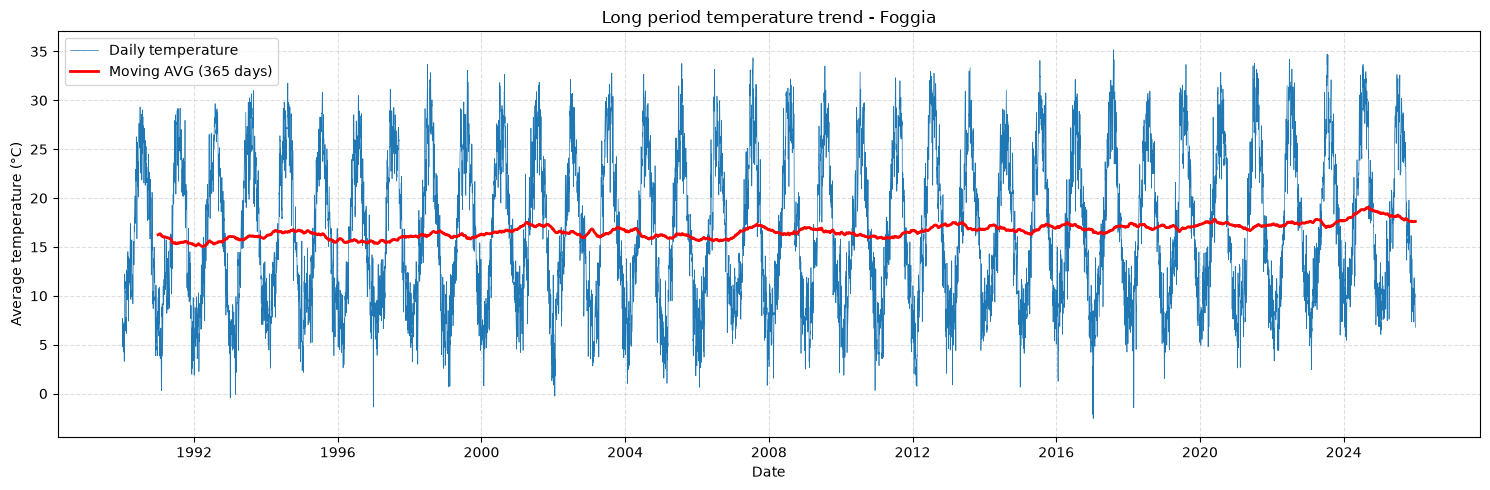

Missing values: 0
count    13148.000000
mean        16.643189
std          7.717068
min         -2.550818
25%         10.092841
50%         15.891674
75%         23.105884
max         35.174905
Name: t2m_mean, dtype: float64


In [23]:
#TIME SERIES TREND 

import matplotlib.pyplot as plt
import pandas as pd
from src.data.preprocessing import load_daily

df_daily = load_daily()

series = df_daily["t2m_mean"].sort_index()

rolling_mean = series.rolling(
    window=365,
    min_periods=365
).mean()

plt.figure(figsize=(15, 5))

plt.plot(
    series.index,
    series.values,
    color="tab:blue",
    linewidth=0.5,
    label="Daily temperature"
)

plt.plot(
    rolling_mean.index,
    rolling_mean.values,
    color="red",
    linewidth=2,
    label="Moving AVG (365 days)"
)

plt.title("Long period temperature trend - Foggia")
plt.xlabel("Date")
plt.ylabel("Average temperature (°C)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

# Verifica dei valori mancanti e statistiche descrittive
print("Missing values:", series.isna().sum())
print(series.describe())


COMMENT: Using a moving average we can observe that the temperatures are rising

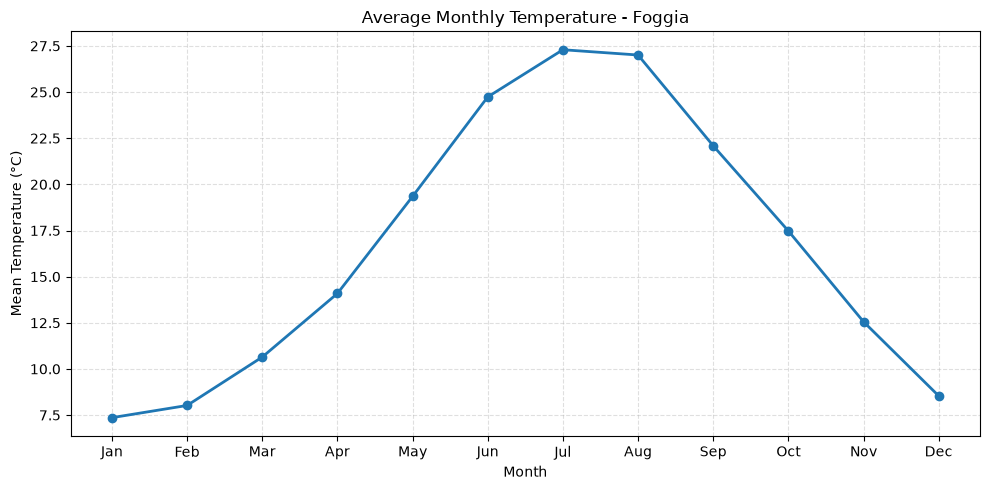

In [24]:
#Seasonality

monthly_mean = series.groupby(series.index.month).mean()

month_labels = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_mean.index,
    monthly_mean.values,
    marker="o",
    linewidth=2
)

plt.xticks(range(1, 13), month_labels)
plt.title("Average Monthly Temperature - Foggia")
plt.xlabel("Month")
plt.ylabel("Mean Temperature (°C)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

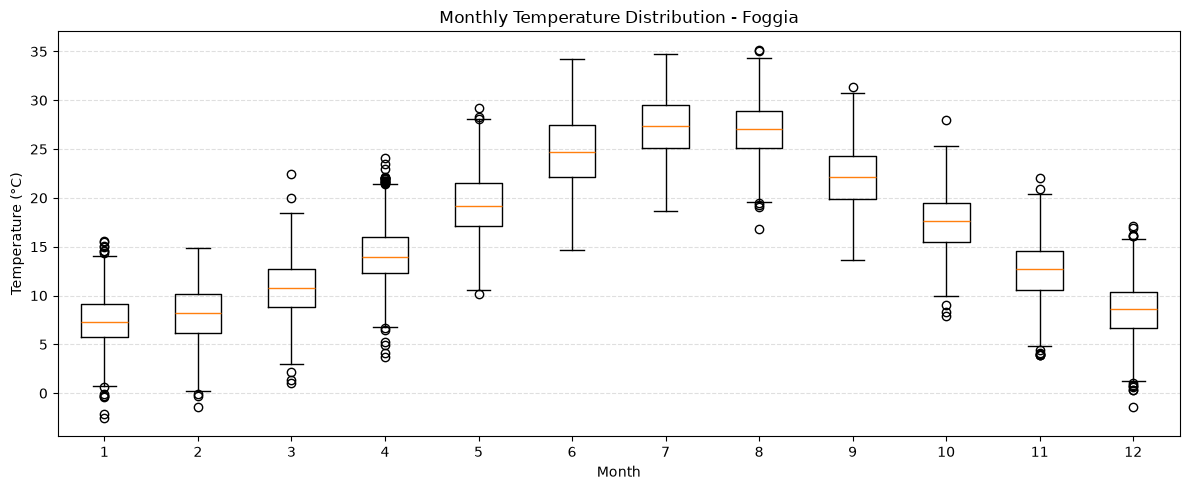

In [25]:
#Seasonality box-plot

df_plot = pd.DataFrame({
    "month": series.index.month,
    "temperature": series.values
})

data_by_month = [
    df_plot.loc[
        df_plot["month"] == month,
        "temperature"
    ]
    for month in range(1, 13)
]

plt.figure(figsize=(12, 5))

plt.boxplot(data_by_month, label=month_labels)

plt.title("Monthly Temperature Distribution - Foggia")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.grid(True, axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

COMMENT: Typical seasonal pattern of the mediterranean

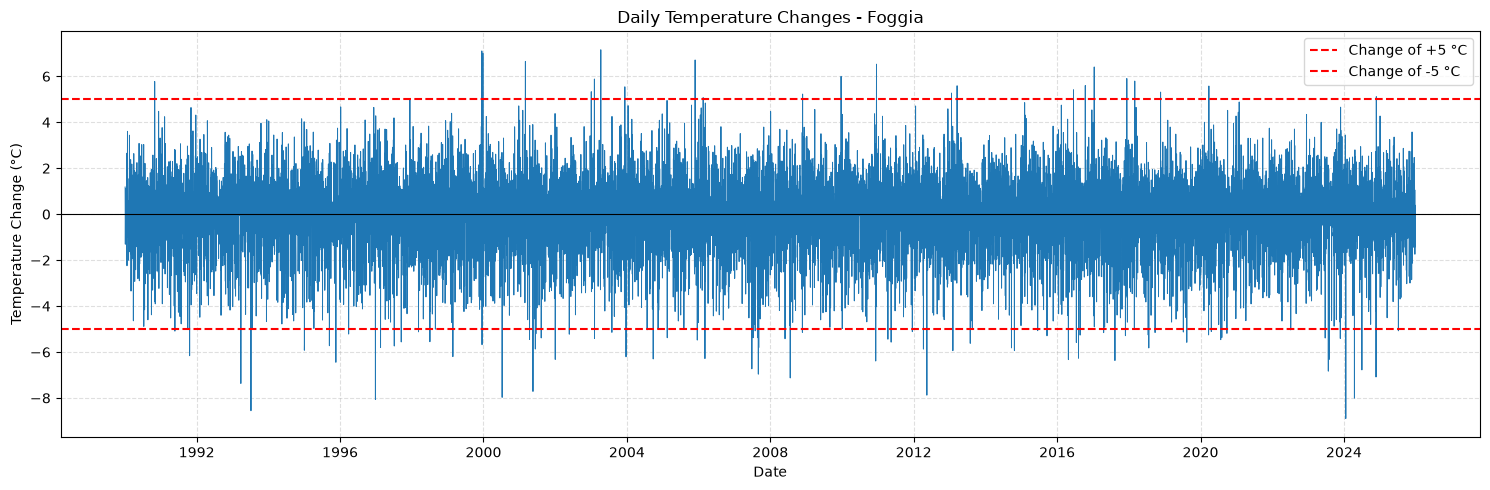

Daily changes exceeding 5 °C:
date
1990-10-30    5.775691
1991-05-24   -5.089060
1991-10-21   -6.159368
1993-03-26   -7.367940
1993-07-07   -8.553828
                ...   
2024-04-17   -8.006226
2024-07-02   -6.777990
2024-11-23   -7.086568
2024-11-26    5.115130
2025-07-09   -5.075607
Name: t2m_mean, Length: 109, dtype: float64


In [26]:
daily_change = series.diff()

plt.figure(figsize=(15, 5))

plt.plot(
    daily_change.index,
    daily_change.values,
    linewidth=0.7
)

plt.axhline(0, color="black", linewidth=0.8)
plt.axhline(
    5, color="red", linestyle="--",
    label="Change of +5 °C"
)
plt.axhline(
    -5, color="red", linestyle="--",
    label="Change of -5 °C"
)

plt.title("Daily Temperature Changes - Foggia")
plt.xlabel("Date")
plt.ylabel("Temperature Change (°C)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

# Identify large day-to-day changes
sudden_changes = daily_change[daily_change.abs() > 5]

print("Daily changes exceeding 5 °C:")
print(sudden_changes)

COMMENT: a -8 degrees variation in 2024 => BURIAN wind

### STL decomposition

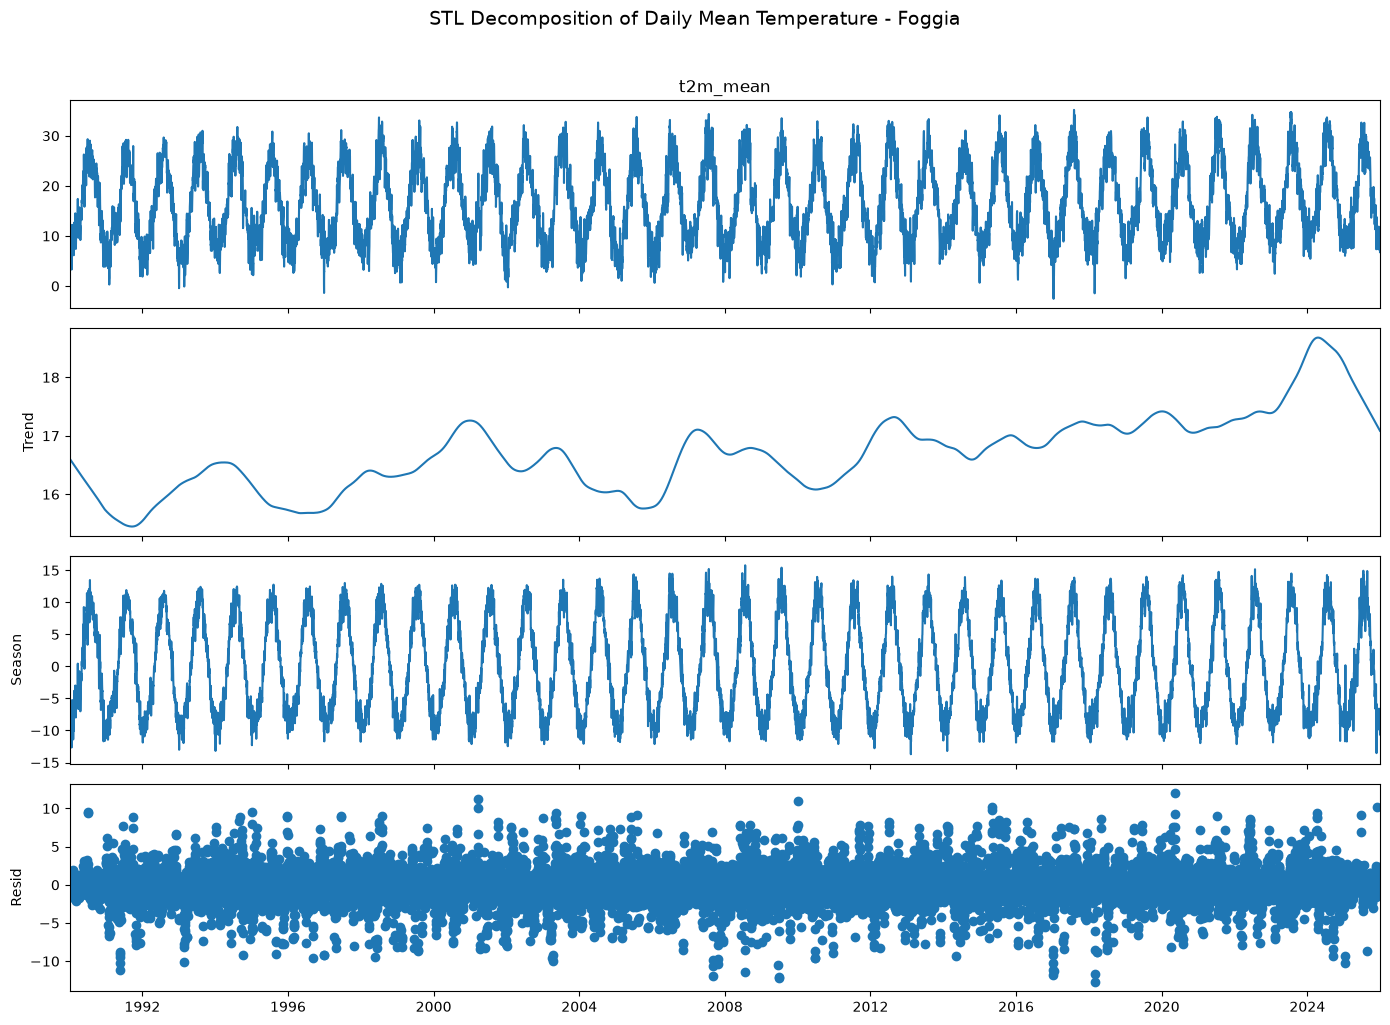

In [27]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

from src.data.preprocessing import load_daily

# Load daily weather data
df_daily = load_daily()

# Extract daily mean temperature
series = df_daily["t2m_mean"].copy()
series.index = pd.to_datetime(series.index)
series = series.sort_index()

# Apply STL decomposition
stl = STL(
    series,
    period=365,
    robust=True
)

result = stl.fit()

# Plot the decomposition
fig = result.plot()
fig.set_size_inches(14, 10)
fig.suptitle(
    "STL Decomposition of Daily Mean Temperature - Foggia",
    fontsize=14,
    y=1.02
)
plt.tight_layout()
plt.show()

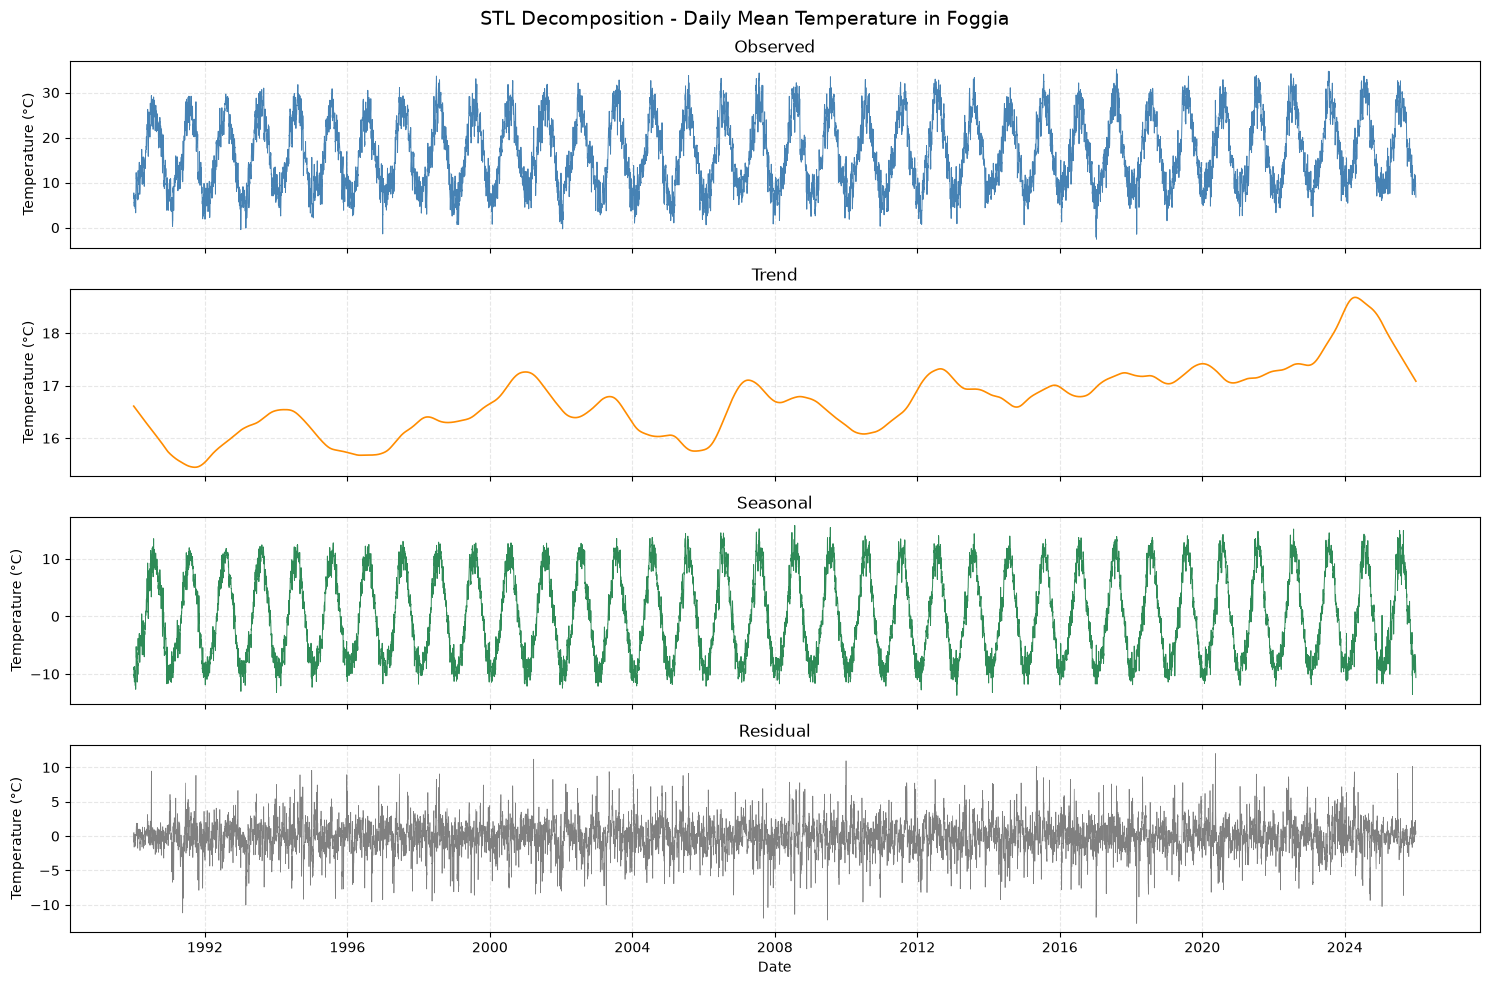

In [28]:
fig, axes = plt.subplots(
    4, 1,
    figsize=(15, 10),
    sharex=True
)

# Observed series
axes[0].plot(
    series.index, series.values,
    linewidth=0.7, color="steelblue"
)
axes[0].set_title("Observed")

# Trend
axes[1].plot(
    result.trend.index, result.trend.values,
    linewidth=1.2, color="darkorange"
)
axes[1].set_title("Trend")

# Seasonal component
axes[2].plot(
    result.seasonal.index, result.seasonal.values,
    linewidth=0.7, color="seagreen"
)
axes[2].set_title("Seasonal")

# Residual component
axes[3].plot(
    result.resid.index, result.resid.values,
    linewidth=0.5, color="gray"
)
axes[3].set_title("Residual")

for ax in axes:
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.set_ylabel("Temperature (°C)")

axes[-1].set_xlabel("Date")

fig.suptitle(
    "STL Decomposition - Daily Mean Temperature in Foggia",
    fontsize=14
)

plt.tight_layout()
plt.show()

#### COMMENT
Again we can see the seasonality in the third graph and in second one we can observe how the temperatures have risen even better than my moving average graph (global warming)

### Mann–Kendall Trend Analysis


In [29]:
import pymannkendall as mk

# Apply the Mann-Kendall test
result = mk.original_test(series)

print("Trend:", result.trend)
print("p-value:", result.p)
print("Kendall's tau:", result.Tau)
print("Sen's slope (°C/day):", result.slope)
print("Sen's slope (°C/year):", result.slope * 365)

# Interpret statistical significance
alpha = 0.05

if result.p < alpha:
    if result.trend == "increasing":
        print("A statistically significant increasing trend was detected.")
    elif result.trend == "decreasing":
        print("A statistically significant decreasing trend was detected.")
else:
    print("No statistically significant monotonic trend was detected.")

Trend: increasing
p-value: 0.0
Kendall's tau: 0.049075975948547824
Sen's slope (°C/day): 0.00015275044953941475
Sen's slope (°C/year): 0.05575391408188639
A statistically significant increasing trend was detected.


##### COMMENT
The Mann–Kendall test detected a statistically significant increasing monotonic trend in the daily mean temperature series for Foggia (p-value = 0). 

Kendall's tau (is between -1 and +1) was approximately 0.049, indicating a weak positive monotonic association between time and temperature. Sen's slope was estimated at approximately 0.000153 °C per day, corresponding to an annualized trend of about 0.056 °C per year.

These results suggest a gradual increase in temperature over the observation period. However, statistical significance should not be confused with the magnitude of the trend.


### Stationarity test

In [30]:
from statsmodels.tsa.stattools import adfuller, kpss

adf_result = adfuller(series)

print(f"ADF p-value:        {adf_result[1]:.6f}")

kpss_result = kpss(series)

print(f"KPSS p-value:        {kpss_result[1]:.6f}")


ADF p-value:        0.000000
KPSS p-value:        0.100000


C:\Users\sahil\AppData\Local\Temp\ipykernel_8072\4269171320.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = adfuller(series)
C:\Users\sahil\AppData\Local\Temp\ipykernel_8072\4269171320.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_result = kpss(series)
C:\Users\sahil\AppData\Local\Temp\ipykernel_8072\4269171320.py:7: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `lags` when store=True). In release 0.16 or after July 2027, whichever is later, the d

#### COMMENT
The ADF and KPSS tests provide results consistent with stationarit. However, the Mann–Kendall test detected a statistically significant increasing trend. Therefore, stationarity of the original temperature series cannot be conclusively established, and the effects of trend and annual seasonality should be investigated further.


### Autocorrelation analysis

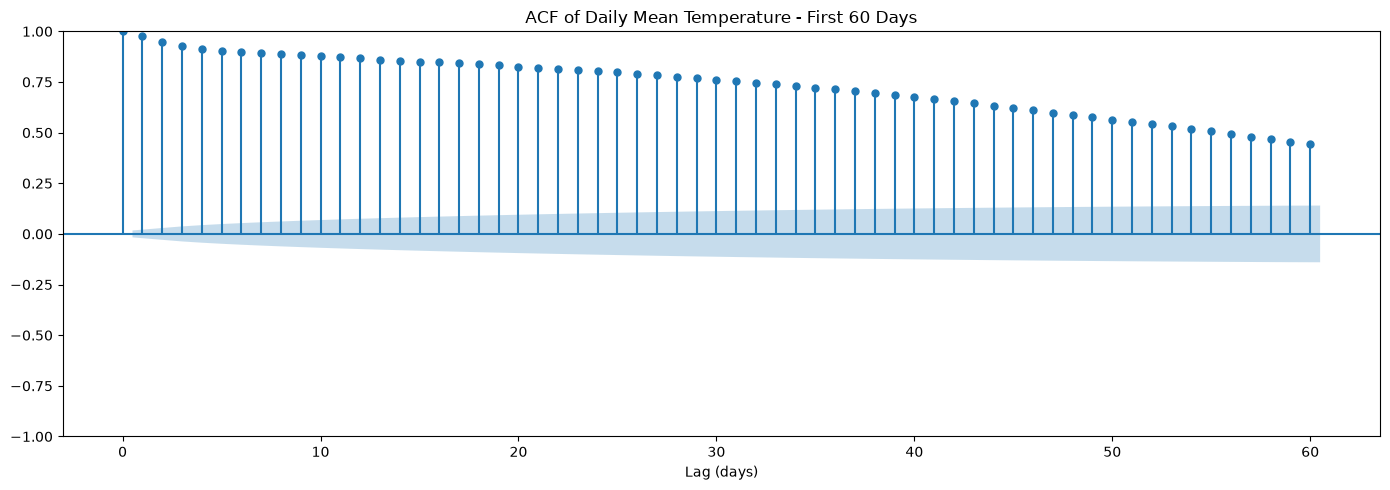

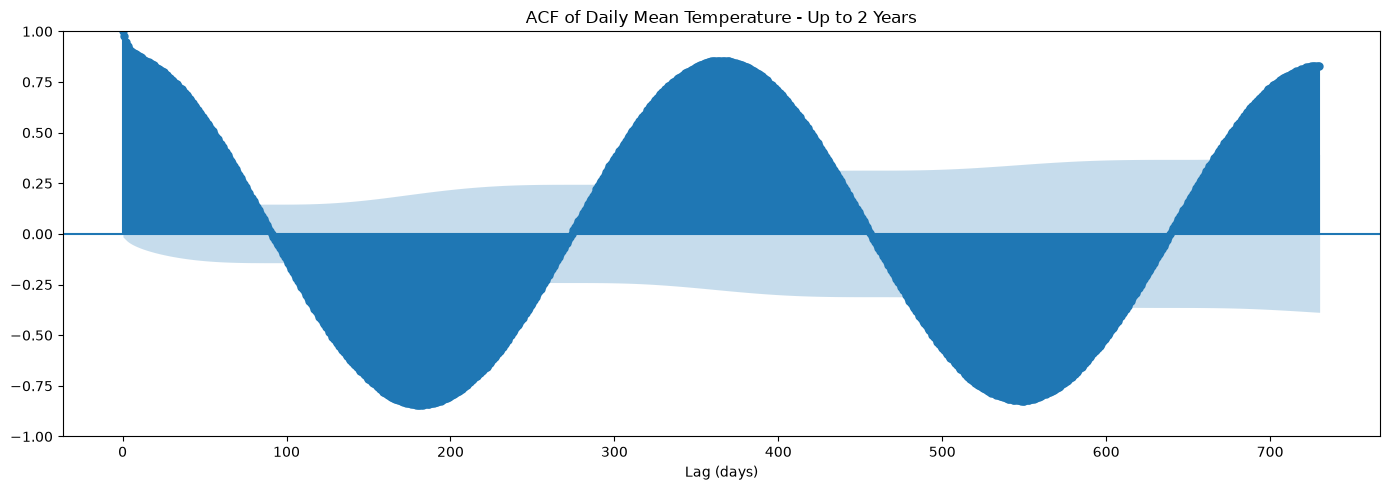

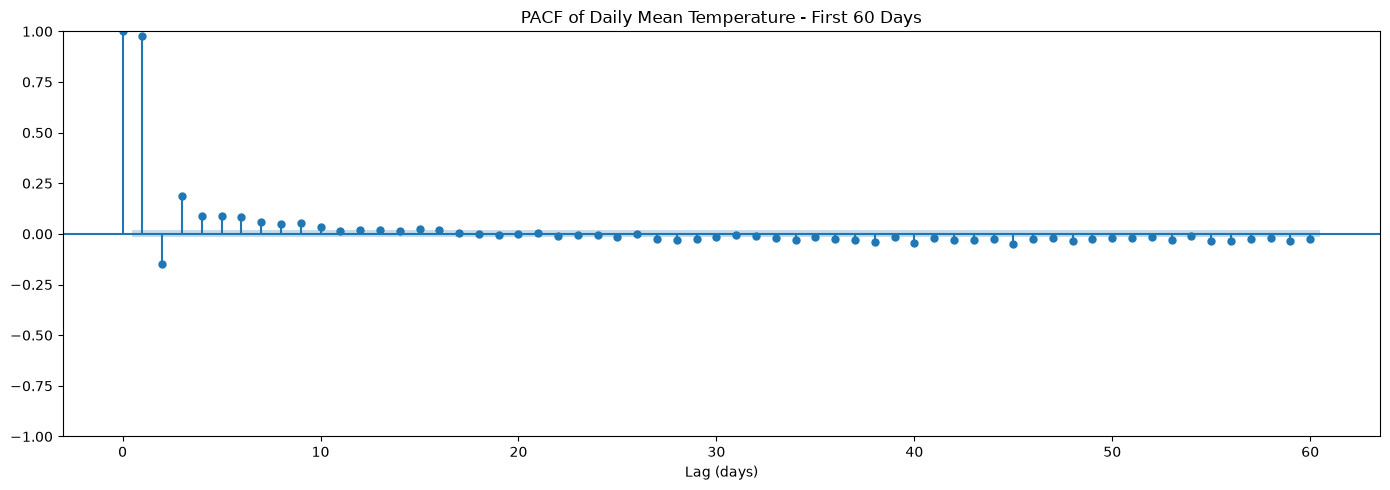

In [31]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ACF: short-term dependence
fig, ax = plt.subplots(figsize=(14, 5))
plot_acf(series, lags=60, ax=ax)
ax.set_title("ACF of Daily Mean Temperature - First 60 Days")
ax.set_xlabel("Lag (days)")
plt.tight_layout()
plt.show()

# ACF: annual seasonal patterns
fig, ax = plt.subplots(figsize=(14, 5))
plot_acf(series, lags=730, ax=ax)
ax.set_title("ACF of Daily Mean Temperature - Up to 2 Years")
ax.set_xlabel("Lag (days)")
plt.tight_layout()
plt.show()

# PACF: short-term autoregressive structure
fig, ax = plt.subplots(figsize=(14, 5))
plot_pacf(series, lags=60, method="ywm", ax=ax)
ax.set_title("PACF of Daily Mean Temperature - First 60 Days")
ax.set_xlabel("Lag (days)")
plt.tight_layout()
plt.show()

#### COMMENT
From the firs plot we can observe that the autocorrelation decreases gradually till it reaches a value 0.45-ish, so we can say that our time series has correlation from high to moderate in the first 60 days.

While observing the second plot we can say that its obviuos that there is seasonality.

From the third plot i am tempted to say that AR(2) could be a plausible autoregressive structure in the data.

### Removal of trend and seasonality

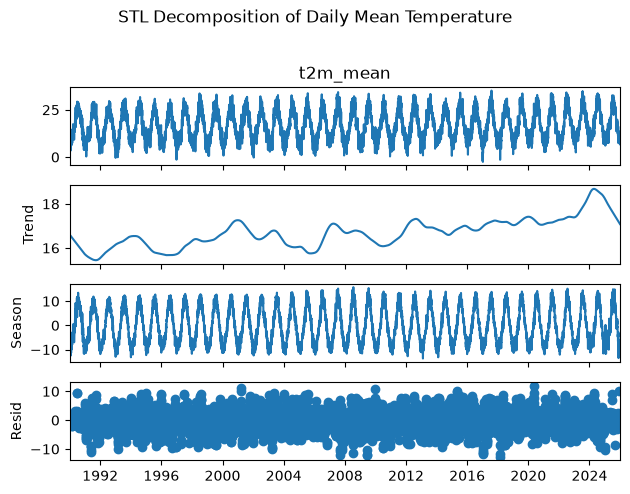

In [32]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

# Decompose the daily mean temperature series
result = STL(series, period=365, robust=True).fit()

# Extract components
detrended = series - result.trend
deseasonalized = series - result.seasonal
residual = result.resid

# Visualize the decomposition
result.plot()
plt.suptitle("STL Decomposition of Daily Mean Temperature", y=1.02)
plt.tight_layout()
plt.show()

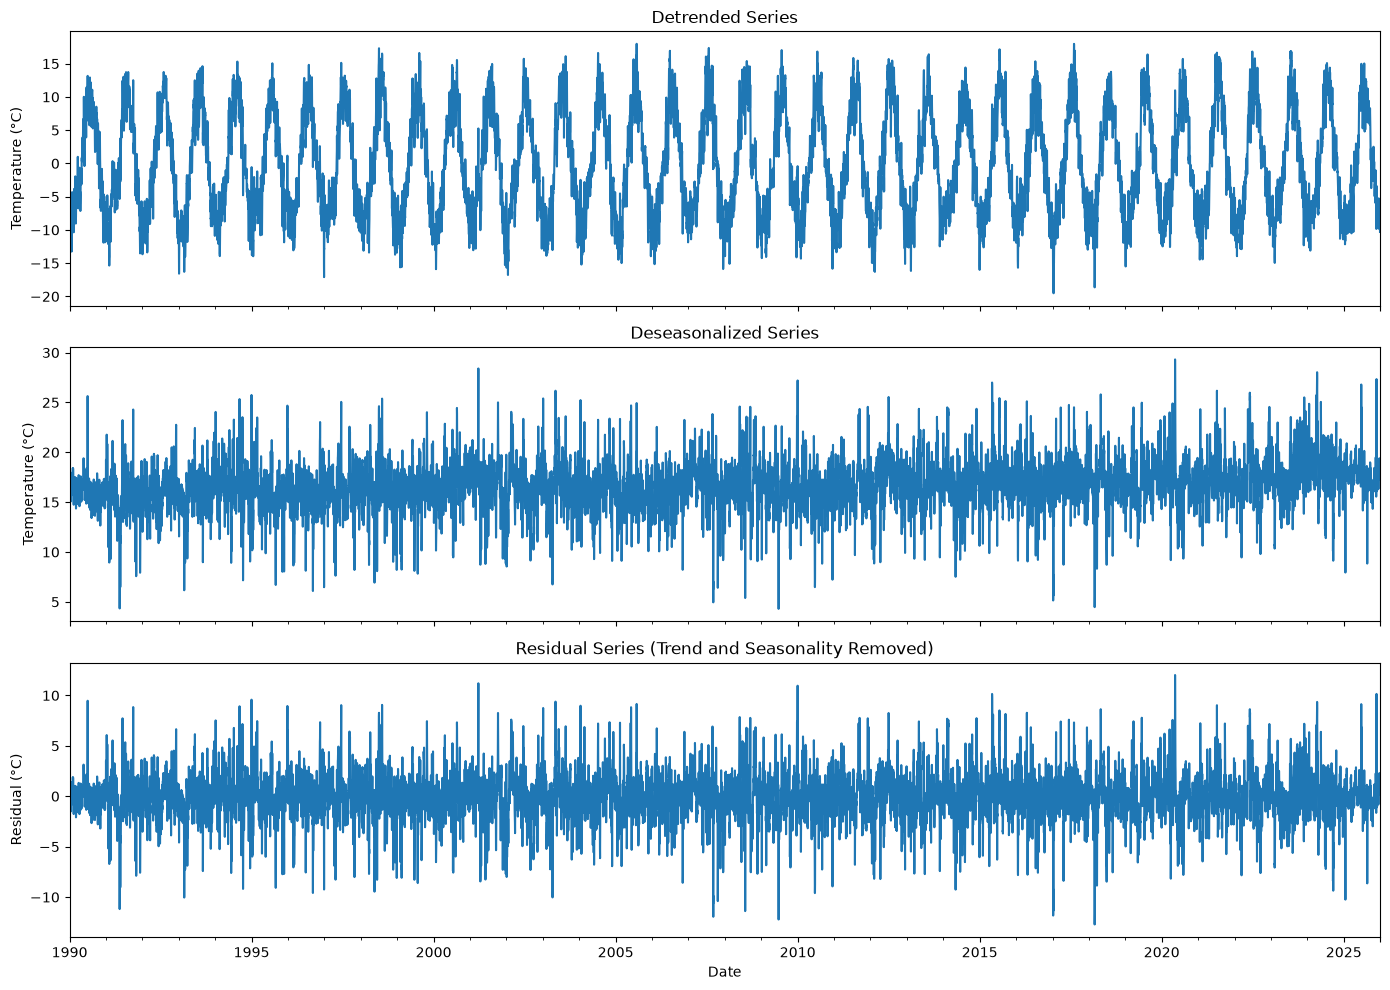

In [33]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

detrended.plot(ax=axes[0])
axes[0].set_title("Detrended Series")
axes[0].set_ylabel("Temperature (°C)")

deseasonalized.plot(ax=axes[1])
axes[1].set_title("Deseasonalized Series")
axes[1].set_ylabel("Temperature (°C)")

residual.plot(ax=axes[2])
axes[2].set_title("Residual Series (Trend and Seasonality Removed)")
axes[2].set_ylabel("Residual (°C)")
axes[2].set_xlabel("Date")

plt.tight_layout()
plt.show()

In [34]:
from statsmodels.tsa.stattools import adfuller, kpss

# Remove missing values, if any
x = residual.dropna()

# ADF test
adf_result = adfuller(x, regression="c", autolag="AIC")

# KPSS test
kpss_result = kpss(x, regression="c", nlags="auto")

print("ADF Test")
print(f"Test statistic: {adf_result[0]:.4f}")
print(f"p-value:        {adf_result[1]:.6f}")
print(f"Lags used:      {adf_result[2]}")

print("\nKPSS Test")
print(f"Test statistic: {kpss_result[0]:.4f}")
print(f"p-value:        {kpss_result[1]:.6f}")
print(f"Lags used:      {kpss_result[2]}")

ADF Test
Test statistic: -27.1693
p-value:        0.000000
Lags used:      10

KPSS Test
Test statistic: 0.0660
p-value:        0.100000
Lags used:      50


C:\Users\sahil\AppData\Local\Temp\ipykernel_8072\30319953.py:7: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = adfuller(x, regression="c", autolag="AIC")
C:\Users\sahil\AppData\Local\Temp\ipykernel_8072\30319953.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_result = kpss(x, regression="c", nlags="auto")
C:\Users\sahil\AppData\Local\Temp\ipykernel_8072\30319953.py:10: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `lags` when store=True). In release 0.1

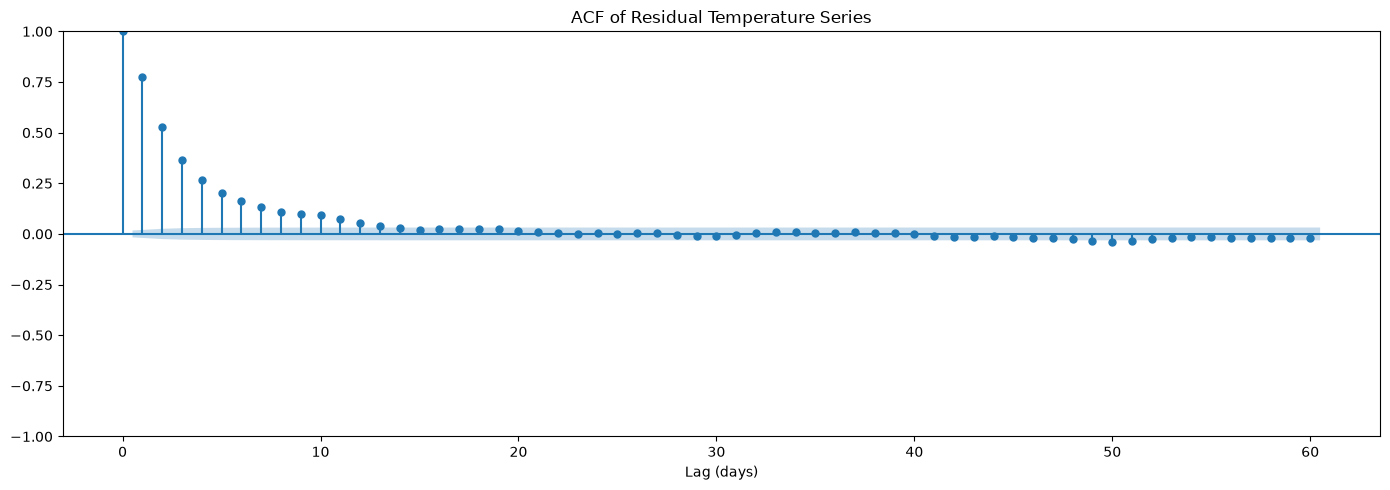

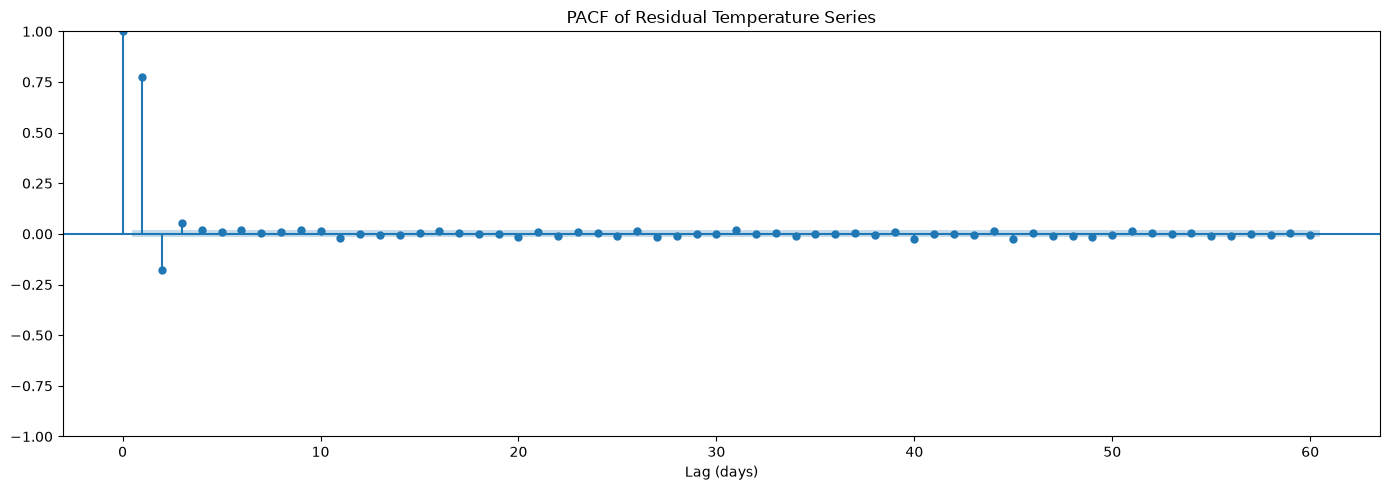

In [35]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ACF
fig, ax = plt.subplots(figsize=(14, 5))
plot_acf(x, lags=60, ax=ax)
ax.set_title("ACF of Residual Temperature Series")
ax.set_xlabel("Lag (days)")
plt.tight_layout()
plt.show()

# PACF
fig, ax = plt.subplots(figsize=(14, 5))
plot_pacf(x, lags=60, method="ywm", ax=ax)
ax.set_title("PACF of Residual Temperature Series")
ax.set_xlabel("Lag (days)")
plt.tight_layout()
plt.show()

#### COMMENT
The series obtained by removing the trend and seasonality component is likely stationary and probably the underlying autoregressive model is AR(2). For the ACF we can observe a more rapid decrease rather than the more gradual we saw on the original series 

## Precipitations analysis

### Initial analysis

Missing values: 0
count    13148.000000
mean         1.435507
std          3.637761
min          0.000000
25%          0.001724
50%          0.071829
75%          0.995498
max         54.826155
Name: tp_mm, dtype: float64


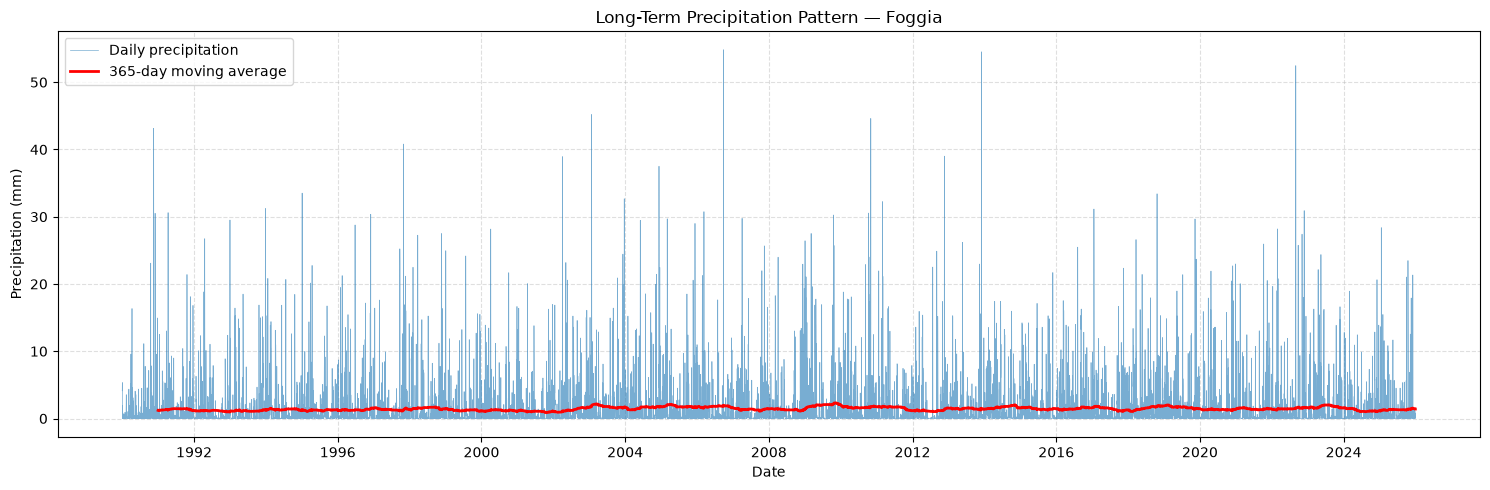

In [42]:

# TIME SERIES TREND — PRECIPITATION

import matplotlib.pyplot as plt
from src.data.preprocessing import load_daily

df_daily = load_daily()
series = df_daily["tp_mm"].sort_index()

# Check missing values
print("Missing values:", series.isna().sum())
print(series.describe())

# 365-observation moving average
rolling_mean = series.rolling(
    window=365,
    min_periods=365
).mean()

# Plot
plt.figure(figsize=(15, 5))

plt.plot(
    series.index,
    series.values,
    color="tab:blue",
    linewidth=0.5,
    alpha=0.6,
    label="Daily precipitation"
)

plt.plot(
    rolling_mean.index,
    rolling_mean.values,
    color="red",
    linewidth=2,
    label="365-day moving average"
)

plt.title("Long-Term Precipitation Pattern — Foggia")
plt.xlabel("Date")
plt.ylabel("Precipitation (mm)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

In [50]:
# Trova la riga in cui la precipitazione giornaliera (tp) è al suo valore massimo
max_precip_row = df_daily.loc[df_daily['tp_mm'].idxmax()]

print("Data dell'evento estremo:", max_precip_row.name)
print("\nValori registrati in questa giornata:")
print(max_precip_row)

Data dell'evento estremo: 2006-09-26 00:00:00

Valori registrati in questa giornata:
t2m_mean      18.460631
t2m_min       17.357324
t2m_max       19.988794
tp_mm         54.826155
e_mm          -1.135709
pev_mm        -1.182139
skt_mean      18.237634
stl1_mean     20.199350
stl2_mean     22.001037
stl3_mean     22.887806
stl4_mean     21.998458
swvl1_mean     0.392222
swvl2_mean     0.328433
swvl3_mean     0.285094
swvl4_mean     0.375449
Name: 2006-09-26 00:00:00, dtype: float64


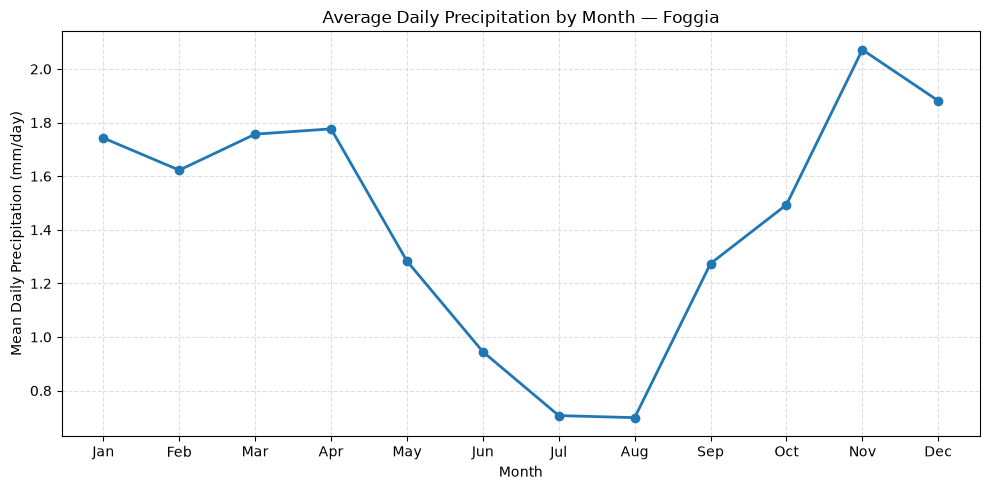

In [43]:

# SEASONALITY — PRECIPITATION

monthly_mean = series.groupby(series.index.month).mean()

month_labels = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_mean.index,
    monthly_mean.values,
    marker="o",
    linewidth=2
)

plt.xticks(range(1, 13), month_labels)
plt.title("Average Daily Precipitation by Month — Foggia")
plt.xlabel("Month")
plt.ylabel("Mean Daily Precipitation (mm/day)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

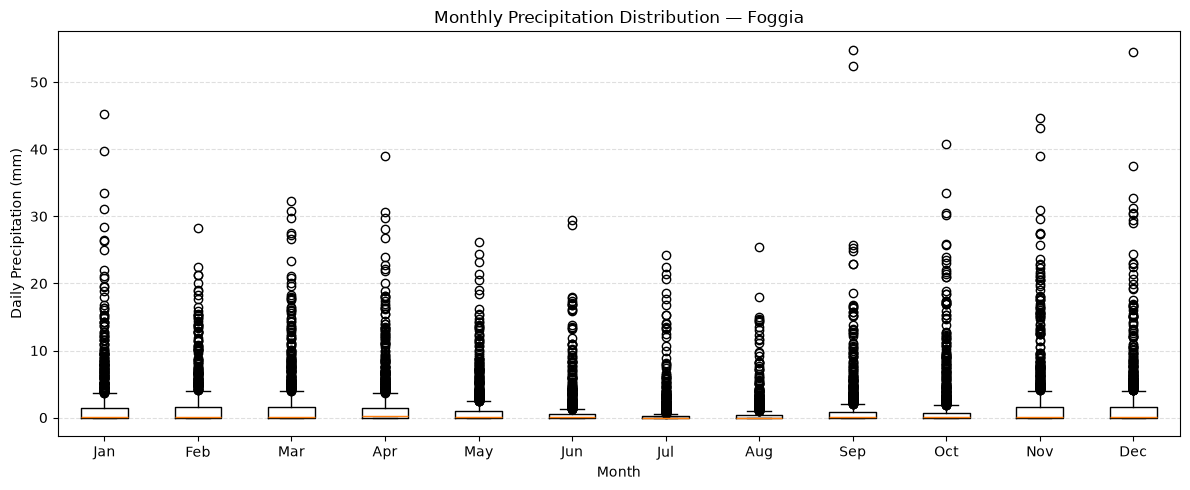

In [44]:

# Seasonality box plot — Precipitation

df_plot = pd.DataFrame({
    "month": series.index.month,
    "precipitation": series.values
})

data_by_month = [
    df_plot.loc[
        df_plot["month"] == month,
        "precipitation"
    ]
    for month in range(1, 13)
]

plt.figure(figsize=(12, 5))

plt.boxplot(data_by_month, tick_labels=month_labels)

plt.title("Monthly Precipitation Distribution — Foggia")
plt.xlabel("Month")
plt.ylabel("Daily Precipitation (mm)")
plt.grid(True, axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

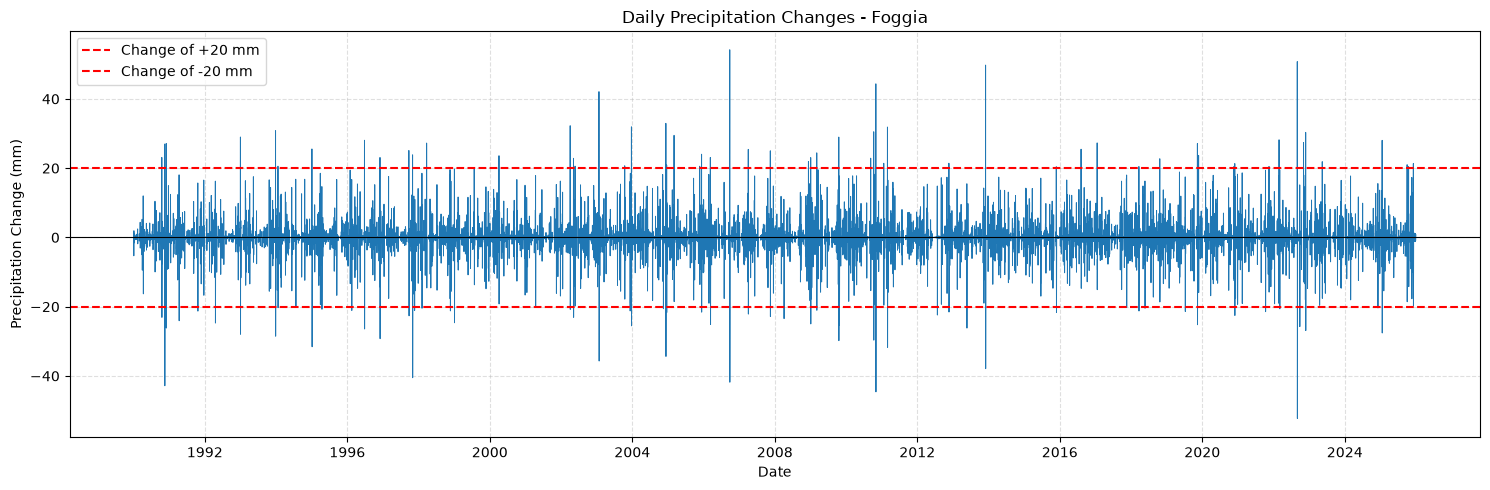

Daily precipitation changes exceeding ±20 mm:
date
1990-10-17    23.090004
1990-10-18   -23.094809
1990-11-15    26.959092
1990-11-17   -42.836653
1990-12-01    27.126417
                ...    
2025-01-18    28.027712
2025-01-19   -27.600370
2025-10-01    20.998281
2025-10-16    20.430824
2025-12-04    21.327865
Name: tp_mm, Length: 119, dtype: float64


In [46]:

# Daily precipitation changes

daily_change = series.diff()

threshold = 20  # mm

plt.figure(figsize=(15, 5))

plt.plot(
    daily_change.index,
    daily_change.values,
    linewidth=0.7
)

plt.axhline(0, color="black", linewidth=0.8)
plt.axhline(
    threshold, color="red", linestyle="--",
    label="Change of +20 mm"
)
plt.axhline(
    -threshold, color="red", linestyle="--",
    label="Change of -20 mm"
)

plt.title("Daily Precipitation Changes - Foggia")
plt.xlabel("Date")
plt.ylabel("Precipitation Change (mm)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

# Identify large day-to-day changes
sudden_changes = daily_change[daily_change.abs() > threshold]

print("Daily precipitation changes exceeding ±20 mm:")
print(sudden_changes)

### STL decomposition

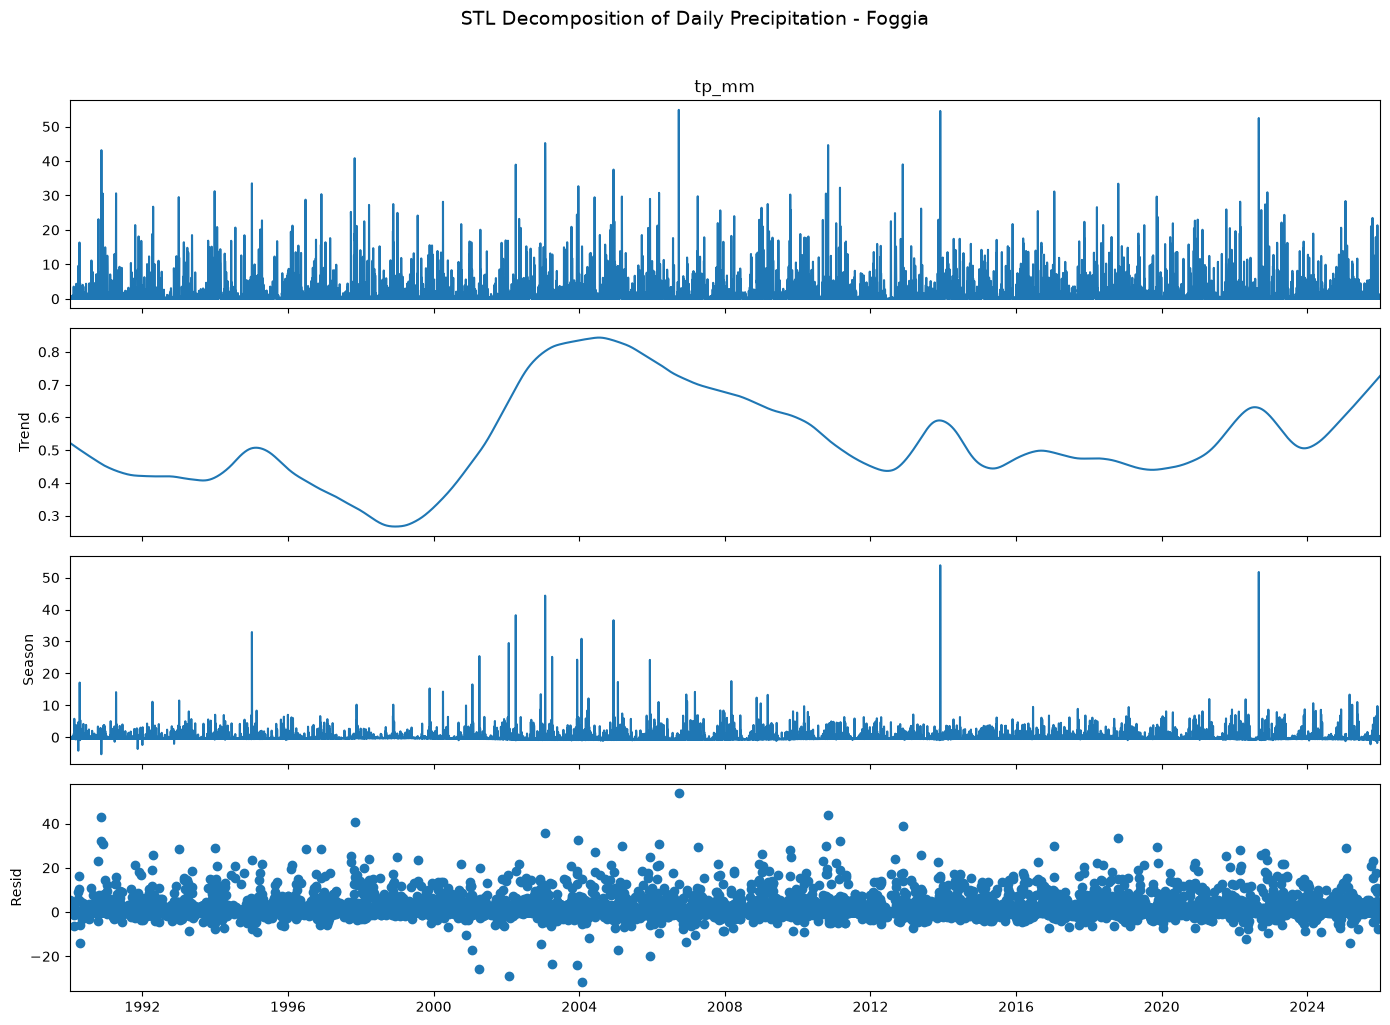

In [51]:

import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.seasonal import STL

from src.data.preprocessing import load_daily

# Load daily weather data
df_daily = load_daily()

# Extract daily precipitation
series = df_daily["tp_mm"].copy()
series.index = pd.to_datetime(series.index)
series = series.sort_index()

# Apply STL decomposition
stl = STL(
    series,
    period=365,
    robust=True
)

result = stl.fit()

# Plot the decomposition
fig = result.plot()
fig.set_size_inches(14, 10)
fig.suptitle(
    "STL Decomposition of Daily Precipitation - Foggia",
    fontsize=14,
    y=1.02
)
plt.tight_layout()
plt.show()

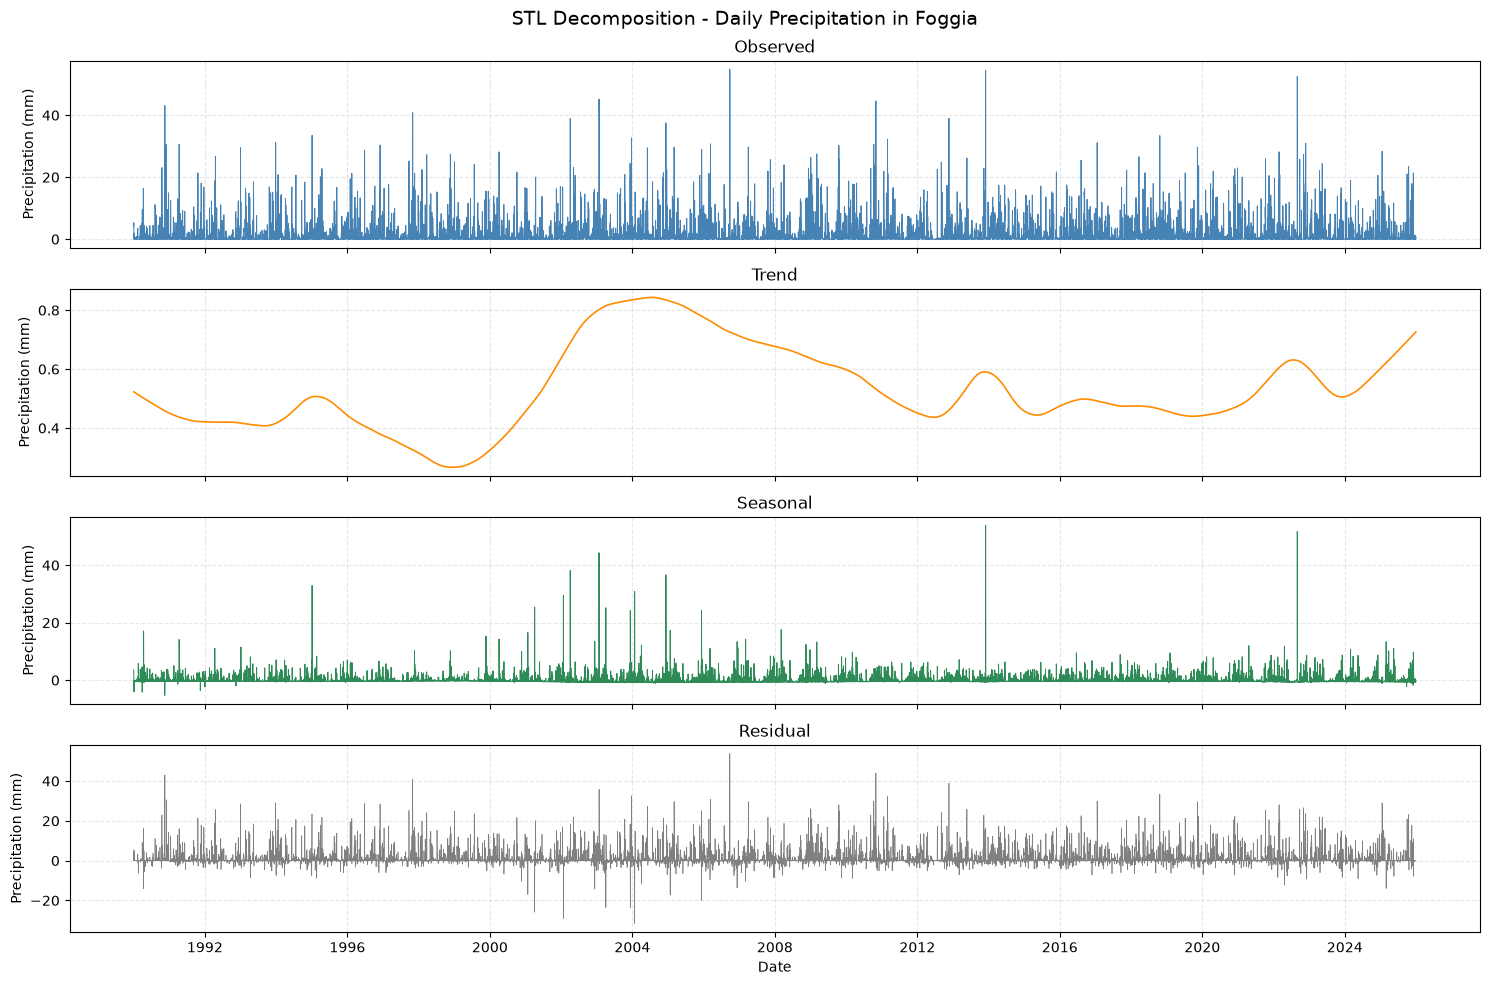

In [52]:

# Plot individual STL components — Precipitation

fig, axes = plt.subplots(
    4, 1,
    figsize=(15, 10),
    sharex=True
)

# Observed series
axes[0].plot(
    series.index, series.values,
    linewidth=0.7, color="steelblue"
)
axes[0].set_title("Observed")

# Trend
axes[1].plot(
    result.trend.index, result.trend.values,
    linewidth=1.2, color="darkorange"
)
axes[1].set_title("Trend")

# Seasonal component
axes[2].plot(
    result.seasonal.index, result.seasonal.values,
    linewidth=0.7, color="seagreen"
)
axes[2].set_title("Seasonal")

# Residual component
axes[3].plot(
    result.resid.index, result.resid.values,
    linewidth=0.5, color="gray"
)
axes[3].set_title("Residual")

for ax in axes:
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.set_ylabel("Precipitation (mm)")

axes[-1].set_xlabel("Date")

fig.suptitle(
    "STL Decomposition - Daily Precipitation in Foggia",
    fontsize=14
)

plt.tight_layout()
plt.show()

### Mann-Kendall trend analysis

In [53]:

import pymannkendall as mk

# Apply the Mann-Kendall test
result = mk.original_test(series)

print("Trend:", result.trend)
print("p-value:", result.p)
print("Kendall's tau:", result.Tau)
print("Sen's slope (mm/day per day):", result.slope)
print("Sen's slope (mm/day per year):", result.slope * 365)

# Interpret statistical significance
alpha = 0.05

if result.p < alpha:
    if result.trend == "increasing":
        print("A statistically significant increasing trend in precipitation was detected.")
    elif result.trend == "decreasing":
        print("A statistically significant decreasing trend in precipitation was detected.")
    else:
        print("No statistically significant increasing or decreasing trend was detected.")
else:
    print("No statistically significant monotonic trend was detected.")

Trend: increasing
p-value: 0.02096868016061304
Kendall's tau: 0.013421899459920445
Sen's slope (mm/day per day): 2.5548336148399523e-08
Sen's slope (mm/day per year): 9.325142694165826e-06
A statistically significant increasing trend in precipitation was detected.


### Stationarity analysis

In [54]:

from statsmodels.tsa.stattools import adfuller, kpss

# ADF test
adf_result = adfuller(series.dropna())

print(f"ADF p-value:  {adf_result[1]:.6f}")

# KPSS test
kpss_result = kpss(series.dropna(), regression="c", nlags="auto")

print(f"KPSS p-value: {kpss_result[1]:.6f}")

ADF p-value:  0.000000
KPSS p-value: 0.069626


C:\Users\sahil\AppData\Local\Temp\ipykernel_8072\609495303.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = adfuller(series.dropna())
C:\Users\sahil\AppData\Local\Temp\ipykernel_8072\609495303.py:9: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `lags` when store=True). In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning a KPSSResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  kpss_result = kpss(series.dropna(), regression="c", nlags="auto")


### Autocorrelation analysis

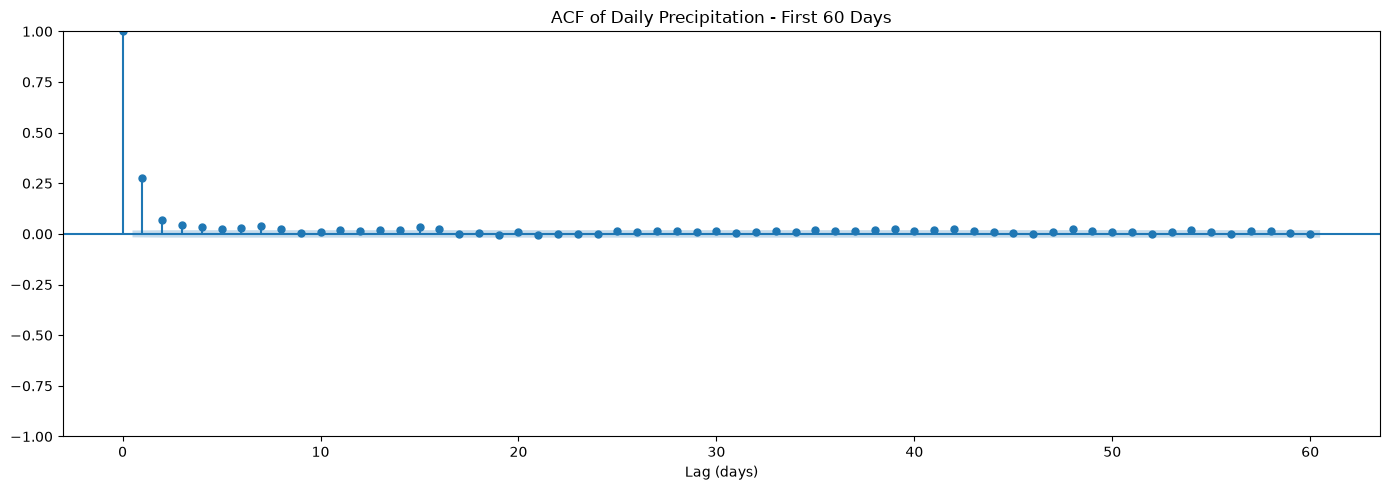

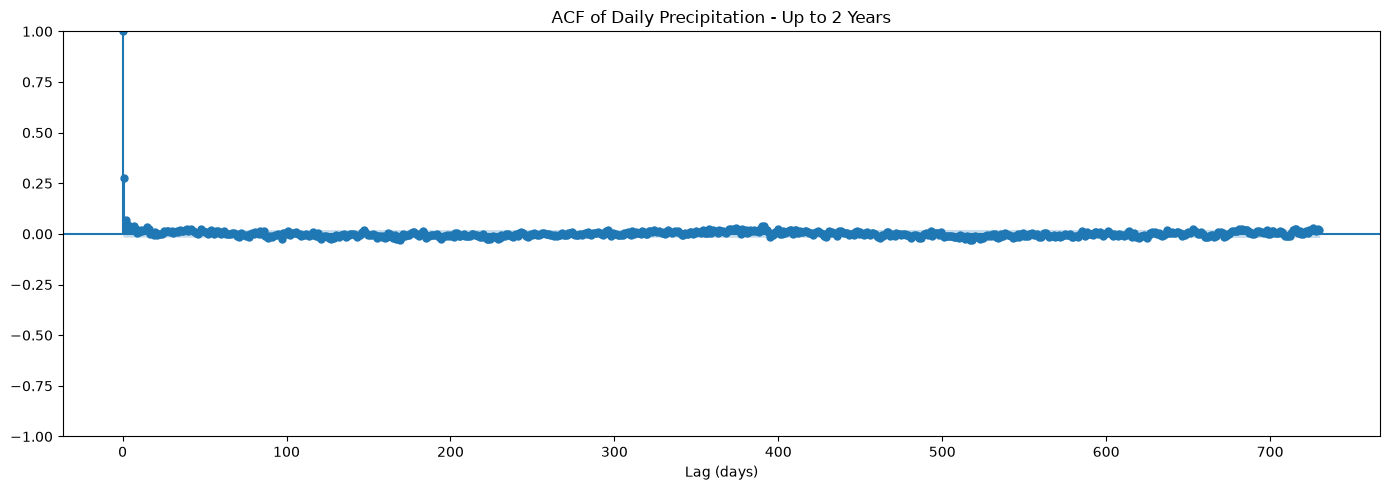

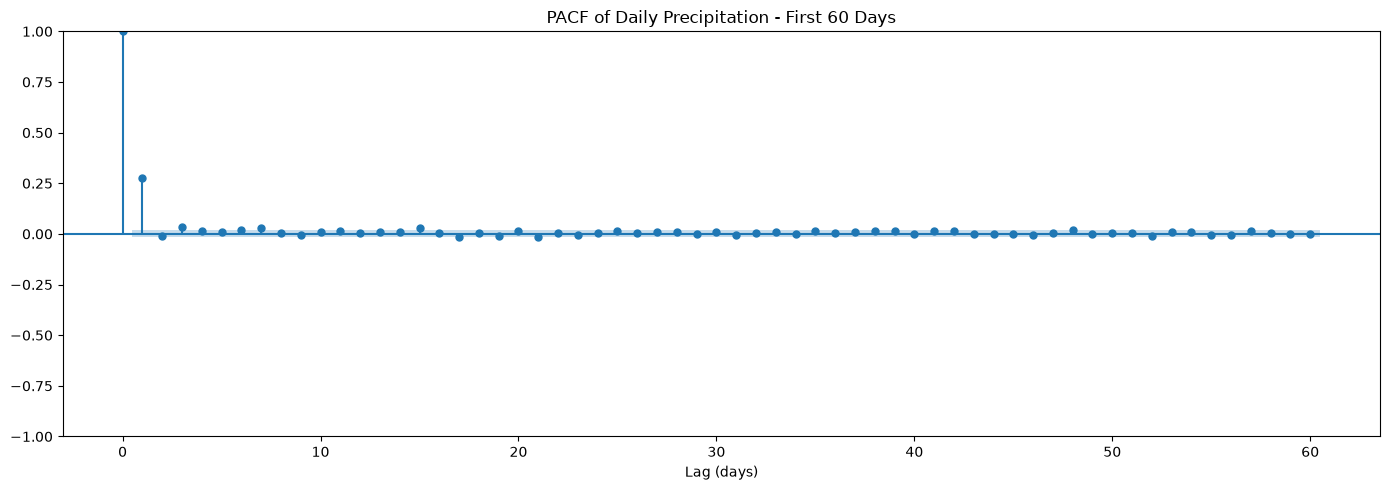

In [55]:

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ACF: short-term dependence
fig, ax = plt.subplots(figsize=(14, 5))
plot_acf(series, lags=60, ax=ax)
ax.set_title("ACF of Daily Precipitation - First 60 Days")
ax.set_xlabel("Lag (days)")
plt.tight_layout()
plt.show()

# ACF: annual seasonal patterns
fig, ax = plt.subplots(figsize=(14, 5))
plot_acf(series, lags=730, ax=ax)
ax.set_title("ACF of Daily Precipitation - Up to 2 Years")
ax.set_xlabel("Lag (days)")
plt.tight_layout()
plt.show()

# PACF: short-term autoregressive structure
fig, ax = plt.subplots(figsize=(14, 5))
plot_pacf(series, lags=60, method="ywm", ax=ax)
ax.set_title("PACF of Daily Precipitation - First 60 Days")
ax.set_xlabel("Lag (days)")
plt.tight_layout()
plt.show()

### Removal of trend and seasonality

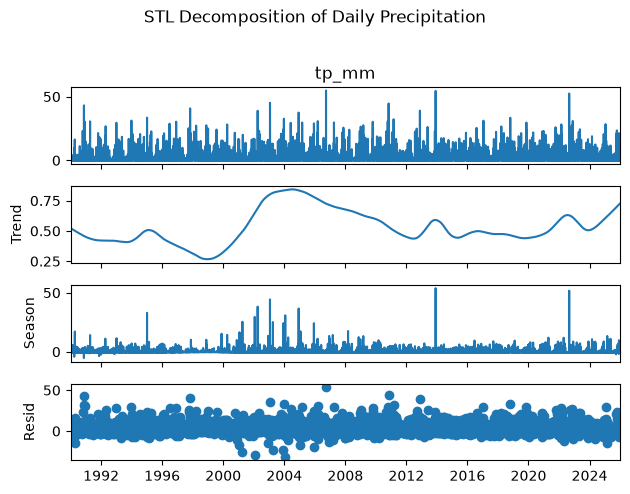

In [60]:

import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

# Decompose the daily precipitation series
result = STL(series, period=365, robust=True).fit()

# Extract components
detrended = series - result.trend
deseasonalized = series - result.seasonal
residual = result.resid

# Visualize the decomposition
result.plot()
plt.suptitle("STL Decomposition of Daily Precipitation", y=1.02)
plt.tight_layout()
plt.show()

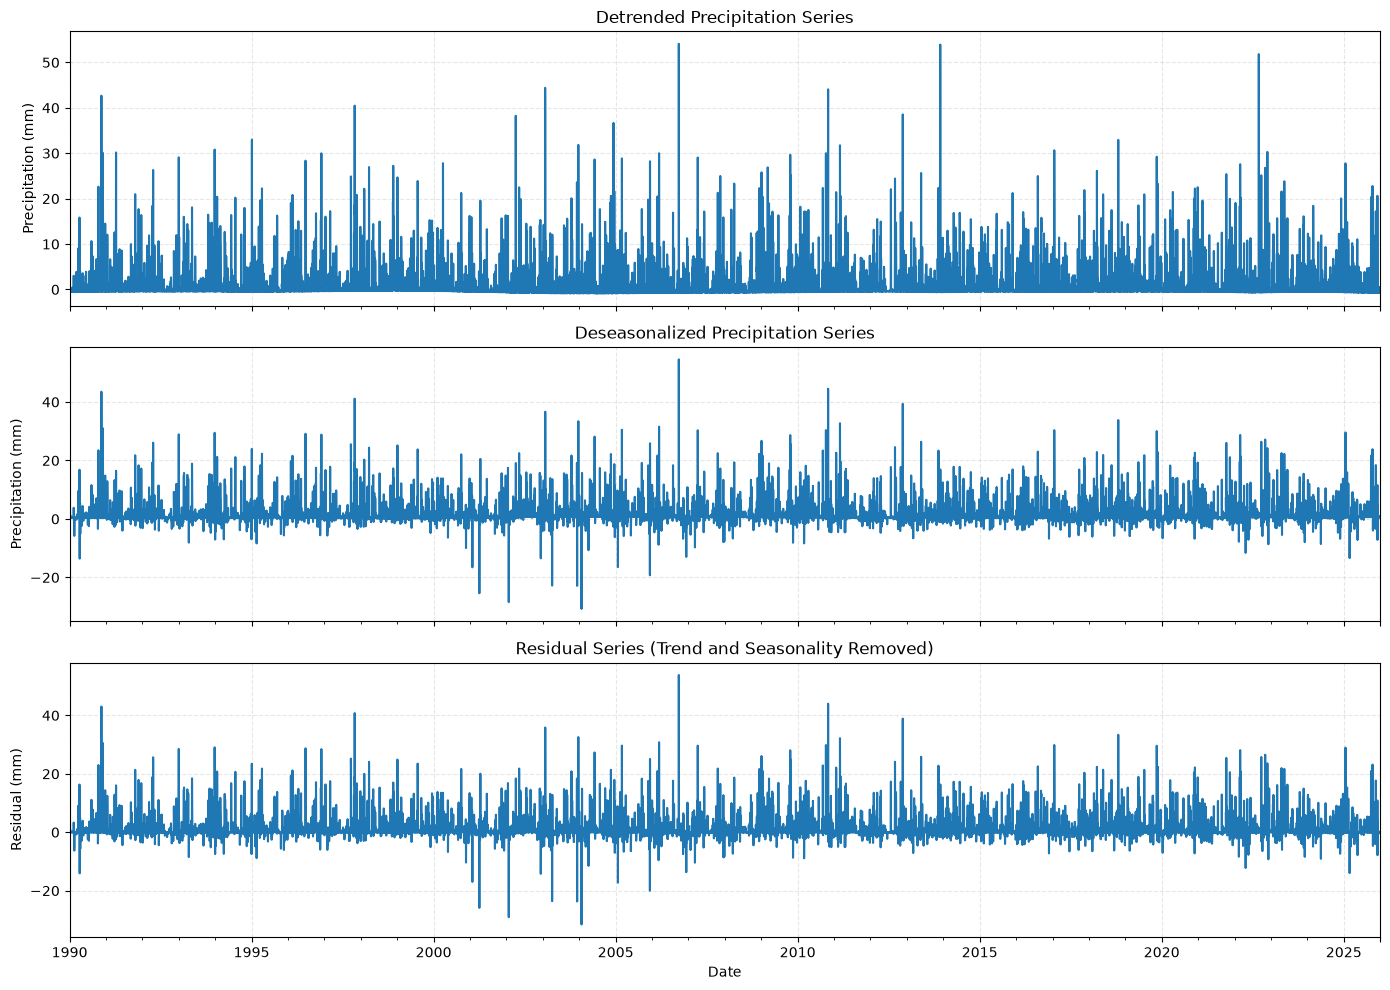

In [61]:

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Detrended series
detrended.plot(ax=axes[0])
axes[0].set_title("Detrended Precipitation Series")
axes[0].set_ylabel("Precipitation (mm)")

# Deseasonalized series
deseasonalized.plot(ax=axes[1])
axes[1].set_title("Deseasonalized Precipitation Series")
axes[1].set_ylabel("Precipitation (mm)")

# Residual series
residual.plot(ax=axes[2])
axes[2].set_title("Residual Series (Trend and Seasonality Removed)")
axes[2].set_ylabel("Residual (mm)")
axes[2].set_xlabel("Date")

for ax in axes:
    ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [62]:

from statsmodels.tsa.stattools import adfuller, kpss
import numpy as np

# Remove missing and infinite values, if any
x = residual.replace([np.inf, -np.inf], np.nan).dropna()

# ADF test
adf_result = adfuller(x, regression="c", autolag="AIC")

# KPSS test
kpss_result = kpss(x, regression="c", nlags="auto")

print("ADF Test - Precipitation Residuals")
print(f"Test statistic: {adf_result[0]:.4f}")
print(f"p-value:        {adf_result[1]:.6f}")
print(f"Lags used:      {adf_result[2]}")

print("\nKPSS Test - Precipitation Residuals")
print(f"Test statistic: {kpss_result[0]:.4f}")
print(f"p-value:        {kpss_result[1]:.6f}")
print(f"Lags used:      {kpss_result[2]}")

ADF Test - Precipitation Residuals
Test statistic: -24.5481
p-value:        0.000000
Lags used:      19

KPSS Test - Precipitation Residuals
Test statistic: 0.2353
p-value:        0.100000
Lags used:      26


C:\Users\sahil\AppData\Local\Temp\ipykernel_8072\1295492349.py:8: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = adfuller(x, regression="c", autolag="AIC")
C:\Users\sahil\AppData\Local\Temp\ipykernel_8072\1295492349.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_result = kpss(x, regression="c", nlags="auto")
C:\Users\sahil\AppData\Local\Temp\ipykernel_8072\1295492349.py:11: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `lags` when store=True). In relea

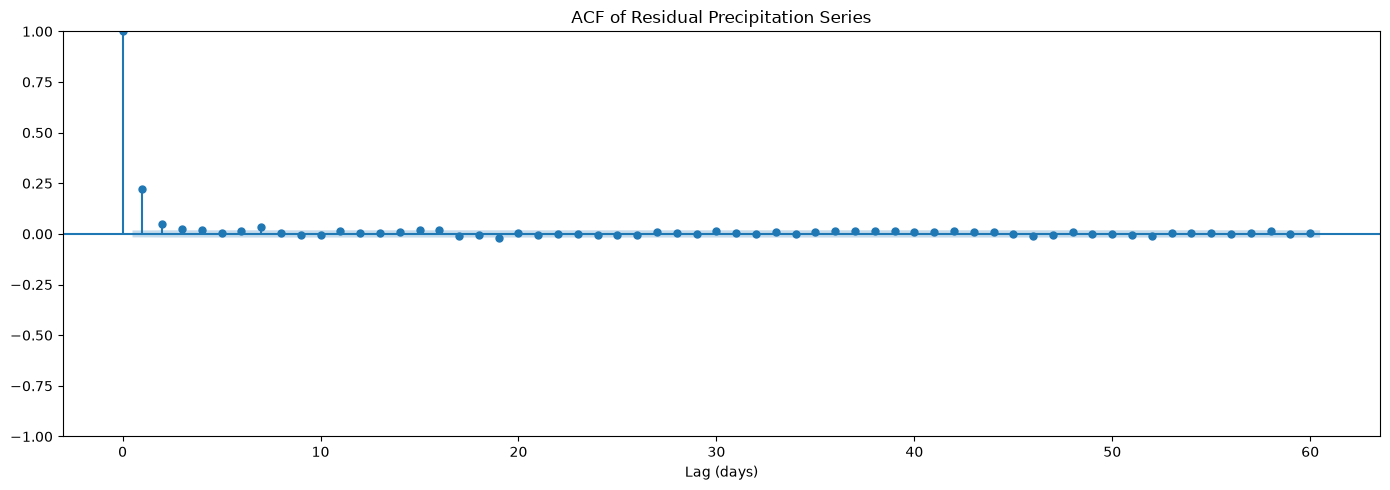

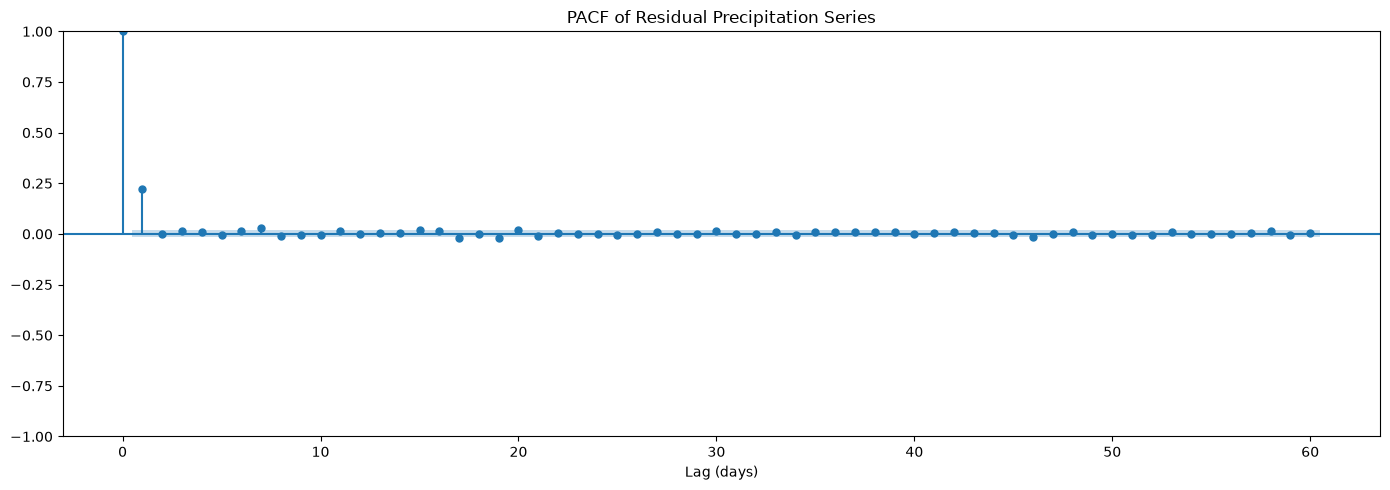

In [63]:

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ACF of precipitation residuals
fig, ax = plt.subplots(figsize=(14, 5))
plot_acf(x, lags=60, ax=ax)
ax.set_title("ACF of Residual Precipitation Series")
ax.set_xlabel("Lag (days)")
plt.tight_layout()
plt.show()

# PACF of precipitation residuals
fig, ax = plt.subplots(figsize=(14, 5))
plot_pacf(x, lags=60, method="ywm", ax=ax)
ax.set_title("PACF of Residual Precipitation Series")
ax.set_xlabel("Lag (days)")
plt.tight_layout()
plt.show()